Abstract:
This project is about predicting failures in a manufacturing dataset. the target is pass or fail. the main problem is that failures are rare, so most models just predict pass. to fix this, we cleaned the data by removing highly correlated features and scaling the numbers. we used smote to make more examples of the failure class so the model could learn patterns instead of only predicting pass. the main model is xgboost because it handles numeric data well and finds patterns between features. we used grid search to pick good parameters like tree depth. we measured performance using recall for the failure class, which tells us how many actual failures the model caught. our model ended up catching almost all failures. we also looked at feature importance to see which variables mattered most. this helps understand what drives failures. overall, the project shows how to handle imbalanced data, build a model that finds failures, and see what features influence the outcome.

ETL without the E(dataset not scraped or recorded by me): Pandas, Numpy 

Visualizations: Seaborn, Matplotlib(pyplot)

Modeling: Xgboost, ImbLearn, Sklearn(model_selection, pre-processing, metrics, svm, ensemble)

System:os

For the sake of limitting the decay of this project, I will have a UV-based venv with a pyproject.toml file and a lock for security, if you intend to run this, initiatelize UV, then call UV sync with the toml file in your local folder to quick install every depenedency present.


In [1]:
# import all packages we actually use here
# numpy pandas seaborn matplotlib sklearn imblearn xgboost
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, recall_score
from xgboost import XGBClassifier, plot_importance
from imblearn.over_sampling import SMOTE


Starting below: I seperate the features and targets in the og data, so that we can have them seperately, then I reassign the binary values of y so that xgboost will take them, it really hates -1.

In [2]:
# load original dataset only
# inspect head to make sure columns match what we expect
data = pd.read_csv("secom_pf_testing.csv")
data.head()
for col in data:
    #since this data is signals in the manufacturing, the absence of a signal(NaN) jsut means that it was not calculated or considered in
    #calculation anyways, so standardize all Nan to 0, for 0=absent signal
    data = data.replace(np.nan, 0)
    #confirm no Null vals
data.isnull().any().any()
x = data.iloc[:, :306].select_dtypes(include=[np.number])
y = data['Pass/Fail'].replace({-1: 0, 1: 1})

# check shapes to make sure separation worked
print("shape of x:", x.shape)
print("shape of y:", y.shape)

shape of x: (1567, 305)
shape of y: (1567,)


To stave off redundant info, I am dropping the highest correlation with others, this reduces the dimensionality of the set, which prevents multicollinearity from hurting the model stability. since the dataset is so skewed towards pass, we need to take some countermeasrues for the sake of accuracy

In [3]:
# remove highly correlated columns using our drop_high_corr function
# looping upper triangle mark all correlations above lim drop duplicates
def drop_high_corr(df, lim):
    corrmap = df.corr()
    gone = []
    cutoff = range(len(corrmap.columns)-1)
    for i in cutoff:
        for j in range(i+1):
            seg = corrmap.iloc[j:(j+1),(i+1):(i+2)]
            a = seg.columns[0]
            b = seg.index[0]
            score = abs(seg.values[0][0])
            if score >= lim:
                print(a,'|',b,'|',round(score,2))
                gone.append(a)
    df = df.drop(columns=list(set(gone)))
    return df

x = drop_high_corr(x, 0.95)
print("shape of x after dropping correlated cols:", x.shape)


5 | 2 | 0.99
27 | 25 | 0.98
38 | 37 | 0.97
49 | 42 | 1.0
50 | 46 | 0.97
54 | 53 | 1.0
55 | 53 | 0.95
56 | 53 | 0.98
56 | 54 | 0.97
56 | 55 | 0.96
57 | 53 | 0.97
57 | 54 | 0.96
57 | 55 | 0.98
57 | 56 | 0.99
58 | 56 | 0.96
66 | 60 | 0.97
69 | 60 | 0.96
69 | 66 | 0.97
70 | 60 | 0.97
70 | 66 | 0.99
70 | 69 | 0.97
73 | 72 | 0.98
96 | 94 | 0.96
104 | 99 | 0.99
105 | 92 | 0.99
106 | 93 | 0.99
110 | 109 | 1.0
111 | 109 | 1.0
111 | 110 | 1.0
123 | 121 | 1.0
124 | 121 | 1.0
124 | 123 | 1.0
127 | 122 | 0.97
131 | 121 | 1.0
131 | 123 | 0.99
131 | 124 | 0.99
133 | 132 | 0.95
140 | 4 | 1.0
148 | 16 | 0.96
152 | 16 | 0.96
152 | 148 | 0.99
165 | 164 | 0.96
174 | 172 | 1.0
206 | 74 | 1.0
209 | 74 | 1.0
209 | 206 | 1.0
220 | 85 | 0.97
246 | 244 | 0.96
246 | 245 | 0.98
249 | 114 | 0.98
252 | 117 | 0.99
271 | 136 | 0.97
272 | 137 | 0.98
274 | 139 | 0.99
275 | 4 | 1.0
275 | 140 | 1.0
277 | 142 | 0.98
279 | 144 | 0.98
280 | 145 | 0.96
281 | 146 | 0.95
282 | 147 | 1.0
283 | 16 | 0.96
283 | 148 | 1.0
283 | 15

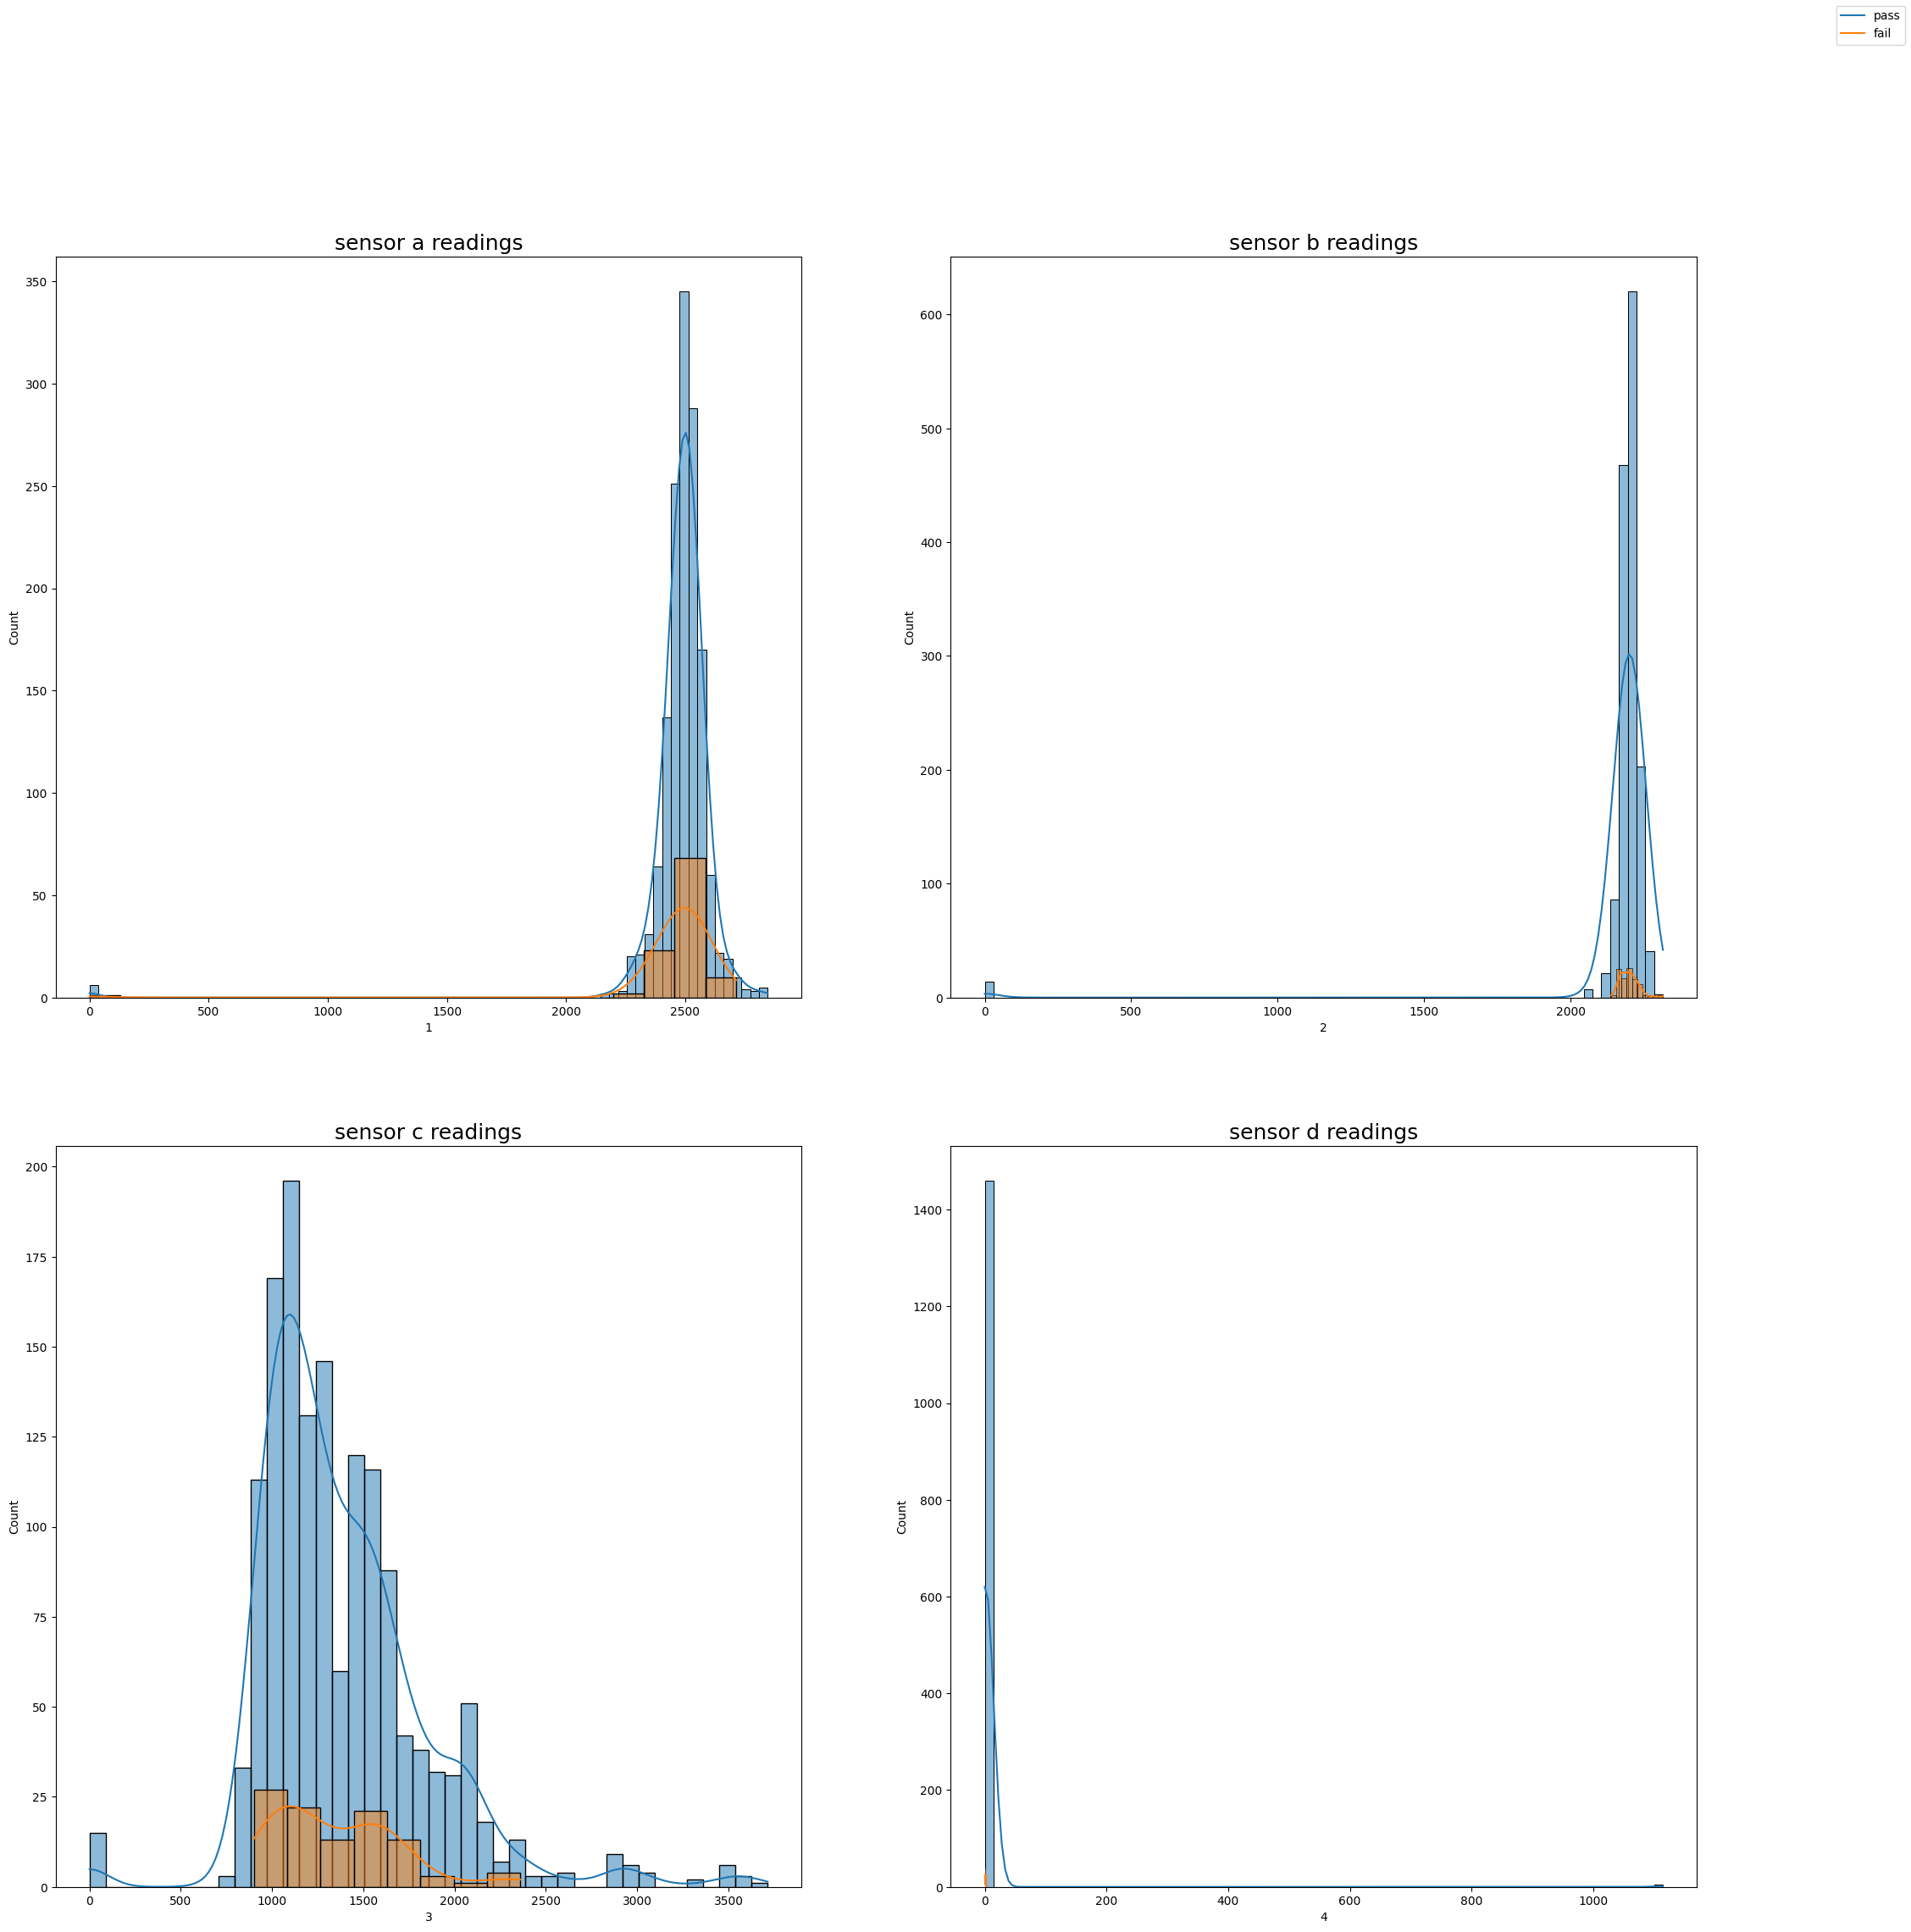

In [4]:
#setup plot canvas
plot_figure = plt.figure(figsize=(25,25))
#variables to visualize a couple individual sensors
unique_vals = data['Pass/Fail'].unique()
targets = [data.loc[data['Pass/Fail'] == val] for val in unique_vals]
#plot subplot 1 for sensor a
plt.subplot(2, 2, 1)
for cls_data in targets:
    sb.histplot(cls_data['1'], kde=True)
plt.title('sensor a readings', fontsize=18)

#plot subplot 2 for sensor b
plt.subplot(2, 2, 2)
for cls_data in targets:
    sb.histplot(cls_data['2'], kde=True)
plt.title('sensor b readings', fontsize=18)

#plot subplot 3 for sensor c
plt.subplot(2, 2, 3)
for cls_data in targets:
    sb.histplot(cls_data['3'], kde=True)
plt.title('sensor c readings', fontsize=18)

#plot subplot 4 for sensor d
plt.subplot(2, 2, 4)
for cls_data in targets:
    sb.histplot(cls_data['4'], kde=True)
plt.title('sensor d readings', fontsize=18)

#add legend pass/fail
plot_figure.legend(labels=['pass','fail'])
plt.show()
#result, we'll need to scale the data so that the lwoer value sensors don't get 
#washed out in analysis, so we will use standard scaling on the numeric data

Getting closer to the meat of this, i split and scale the data. Scaling here keeps the features from getting too uncomparable, which prevents the xgboost model from getting unstable from the differing magnitudes(some sensors report 3000, some report 1-10)

In [5]:
# split into train and test sets random state 1
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)
print("shape x_train:", x_train.shape, "x_test:", x_test.shape)
print("shape y_train:", y_train.shape, "y_test:", y_test.shape)

# scale features standard scaler fit on train transform test
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


shape x_train: (1096, 239) x_test: (471, 239)
shape y_train: (1096,) y_test: (471,)


Fitting our basic xgboost to get a feel of the data, i know from previous work that this will not work well, but its good to get a look at the results before all the tuning and additions. Unfortunately this dataset, even with fixing the differing magnitude issue, is way too skewed to get a great model yet.

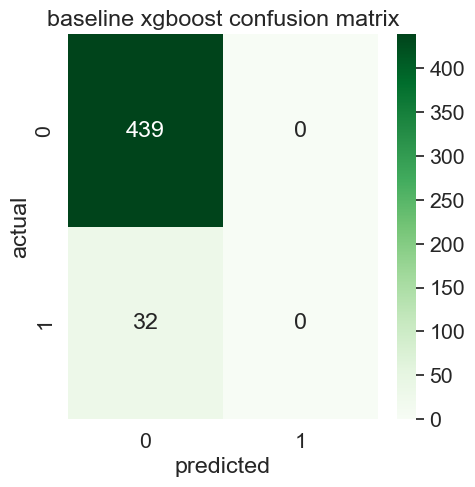

In [6]:
# fit baseline xgboost random_state=1
model = XGBClassifier(random_state=1)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

# confusion matrix just to see how it does
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sb.set(style='dark', font_scale=1.4)
sb.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('baseline xgboost confusion matrix')
plt.show()


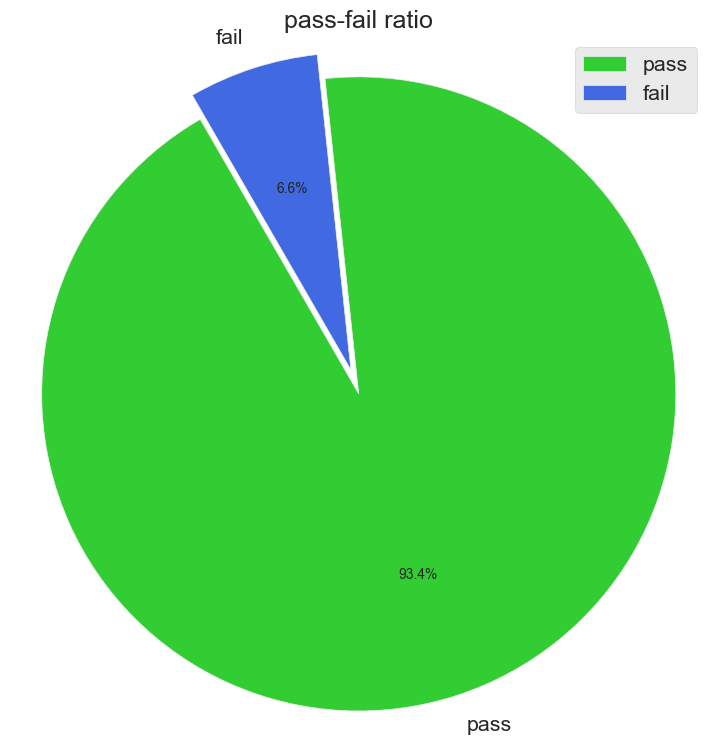

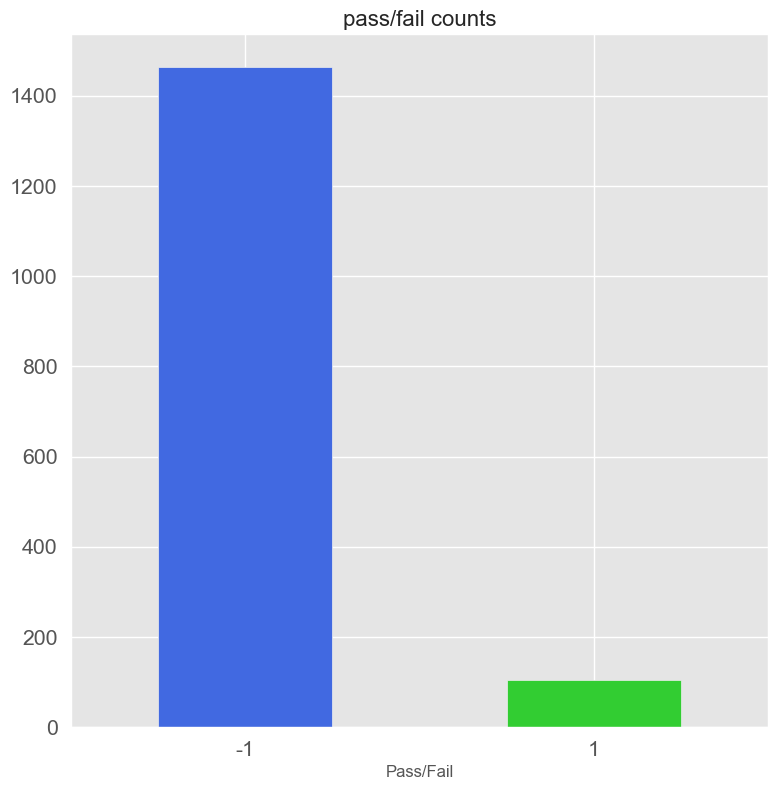

In [ ]:
#count each outcome
pf_counts = data['Pass/Fail'].value_counts()

#basic plot settings
plt.rcParams['figure.figsize'] = (9,9)
plt.style.use('ggplot')

#draw pie chart
explode_parts = [0.08,0]
clr = ['limegreen','royalblue']
names = ['pass','fail']
plt.pie(pf_counts, labels=names, colors=clr, startangle=120, explode=explode_parts,
        autopct='%1.1f%%', shadow=False)
plt.title('pass-fail ratio', fontsize=18)
plt.legend(loc='upper right')
plt.axis('equal')
plt.show()

#draw bar version
pf_counts.plot.bar(color=['royalblue','limegreen'])
plt.title('pass/fail counts', fontsize=16)
plt.xticks(rotation=0)
plt.show()


#Results are what I expected, overwhelmingly pass. This is tough, since we need 
#our model to best identify failure. To get an accurate read on what featrues
#contibute most to fail, I will need to synthesize more data for the
#model to better understand that case

So above, obviously this just shows how much the data informs the model, 90 percent pass. We need to fix that unbalance by giving it more data, so for that I am using smote. the synthetic oversampling will give the model a better look of what a fail case looks like, that way it has more data to pull from. The goal is to find what features most inform p/f yield, so it needs a wholistic look.

Back below: This block has a couple things:
SMOTE oversampling: applies smote to balance the classes, p/f. important for recall accuracy, detecting fail cases better
Train, test, split: redoing the training and splitting with the oversampled data, same logic as prior scaling as well for same reasons

In [ ]:
# smote to create synthetic examples of minority class
y = y.replace({-1:0, 1:1})
#handling of nans before SMOTE
x_clean = x.fillna(0)
y_clean = y.copy()

x_resample, y_resample = SMOTE(random_state=1).fit_resample(x_clean, y_clean.values.ravel())

print(x_resample.shape, y_resample.shape)

#train test split for oveesampled dataset
x_train_os, x_test_os, y_train_os, y_test_os = train_test_split(x_resample, y_resample, test_size=0.3, random_state=1)
print("x_train_os:", x_train_os.shape, "y_train_os:", y_train_os.shape)
print("x_test_os:", x_test_os.shape, "y_test_os:", y_test_os.shape)

# scale oversampled features
sc = StandardScaler()
x_train_os = sc.fit_transform(x_train_os)
x_test_os = sc.transform(x_test_os)
print("data scaling done")


(2926, 239) (2926,)
x_train_os: (2048, 239) y_train_os: (2048,)
x_test_os: (878, 239) y_test_os: (878,)
data scaling done


Again, redoing logic but with the oversampled data. 

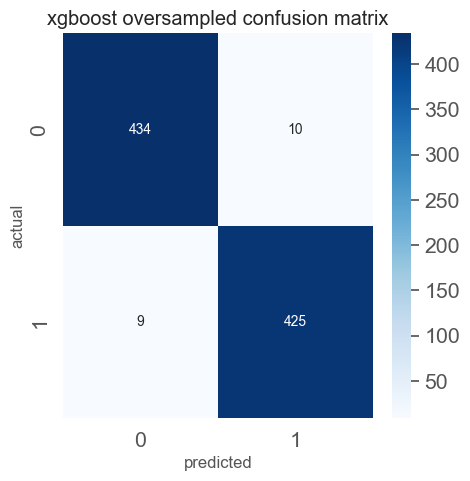

recall for failure class: 0.9792626728110599


In [9]:
# fit xgboost on oversampled train set
model = XGBClassifier(random_state=1)
model.fit(x_train_os, y_train_os)
y_pred_os = model.predict(x_test_os)

# confusion matrix to check recall for failure class
cm = confusion_matrix(y_test_os, y_pred_os)
plt.figure(figsize=(5,5))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('xgboost oversampled confusion matrix')
plt.show()

# recall for minority class
recall = recall_score(y_test_os, y_pred_os, pos_label=1)
print("recall for failure class:", recall)


So above is the good news. This shows that the model has a better understanding of the two cases, and can identify their features better. The recall accuracy for the failure class is also up much higher(prev 0), showing a huge increase in  understanding

To reiterate, the goal is to find the most important features impacting the p/f yield, and train an XGboost model to identify and classify said features. To help with that, I am using the SMOTE func to do oversampling. Smote uses a couplt techniques to do this, specifically by using interpolarity in the dataset(two nearby fails-> new fail between, etc..). This will help our model know what fail cases actually look like compared to pass cases, since the current data doesn't give a nearly equal level of examples. So I am going to retrain after this. 

Issue with this: model results stayed relatively the same. There was slightly more variation but nothing significant. So Now I am going to try a new method grid Search:

Grid search will simulate tests with parameters in the dataset to find the values that are most affecting the result. The reason is helps here is how messy secom manufacturing data is. There is so much going on that my manual tuning has had little effect, so I decided to automate the process


In [10]:
# grid search for max_depth and cv
parameters = {
    'max_depth': [1,2,3,4,5,6],
    'cv':[2,4,6,8,10],
    'random_state':[1]
}

grid_search = GridSearchCV(estimator=model, param_grid=parameters, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train_os, y_train_os)
best_accuracy = grid_search.best_score_
best_parameters = grid_search.best_params_
print("best accuracy:", best_accuracy)
print("best parameters:", best_parameters)


c:\Users\alecl\OneDrive\Desktop\AL REPOS\SECOM_Manufacturing_PF_Model\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:37:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "cv" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


best accuracy: 0.9702152781919018
best parameters: {'cv': 2, 'max_depth': 5, 'random_state': 1}


Below, the feature importance logic:
This uses features importances to identify the top features driving failure, which is only possible now that the model accurately identifies them with the oversampling and grid search
This also validates the model's behavior, showing what features were identified by it.

    Feature  Importance
59       72    6.343275
81       95    3.726602
49       59    3.548678
213     247    3.245927
107     130    2.595781
..      ...         ...
227     263    0.000000
226     262    0.000000
225     261    0.000000
236     276    0.000000
238     284    0.000000

[239 rows x 2 columns]


<Figure size 1200x800 with 0 Axes>

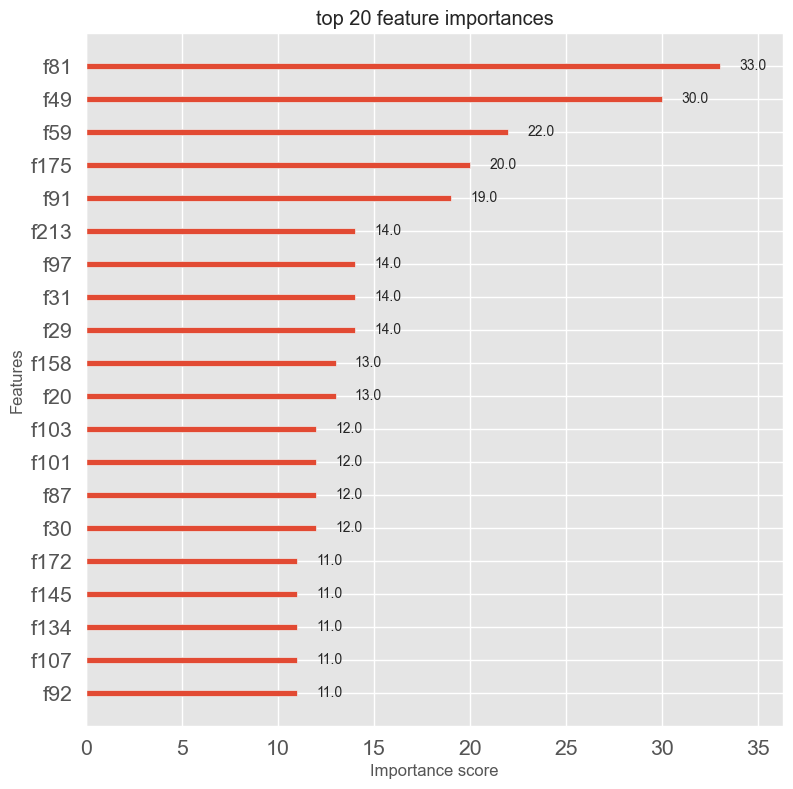

In [11]:
# xgboost feature importance
featureImp = []
for feat, importance in zip(x.columns, model.feature_importances_):
    featureImp.append([feat, importance*100])

fT_df = pd.DataFrame(featureImp, columns=['Feature','Importance'])
print(fT_df.sort_values('Importance', ascending=False))

# optional plot
plt.figure(figsize=(12,8))
plot_importance(model, max_num_features=20, importance_type='weight')
plt.title('top 20 feature importances')
plt.show()


Exporting model for app


In [ ]:
#this is all saving certain objects for the dashboard app3
# save trained xgboost model
joblib.dump(model, "xgb_model.pkl")

# save fitted scaler
joblib.dump(sc, "scaler.pkl")

#save feature names
joblib.dump(list(x.columns), "feature_names.pkl")

# save test set to show in streamlit
joblib.dump(x_test, "x_test.pkl")
joblib.dump(y_test, "y_test.pkl")
# Save feature importance DataFrame
fT_df.to_csv("feature_importance.csv", index=False)


#ave confusion matrix
np.save("confusion_matrix.npy", cm)

y_pred = model.predict(x_test)

#save ytest and pred
np.save("y_test.npy", y_test)
np.save("y_pred.npy", y_pred)

print("Saved y_test.npy and y_pred.npy for dashboard visualization.")




Saved y_test.npy and y_pred.npy for dashboard visualization.


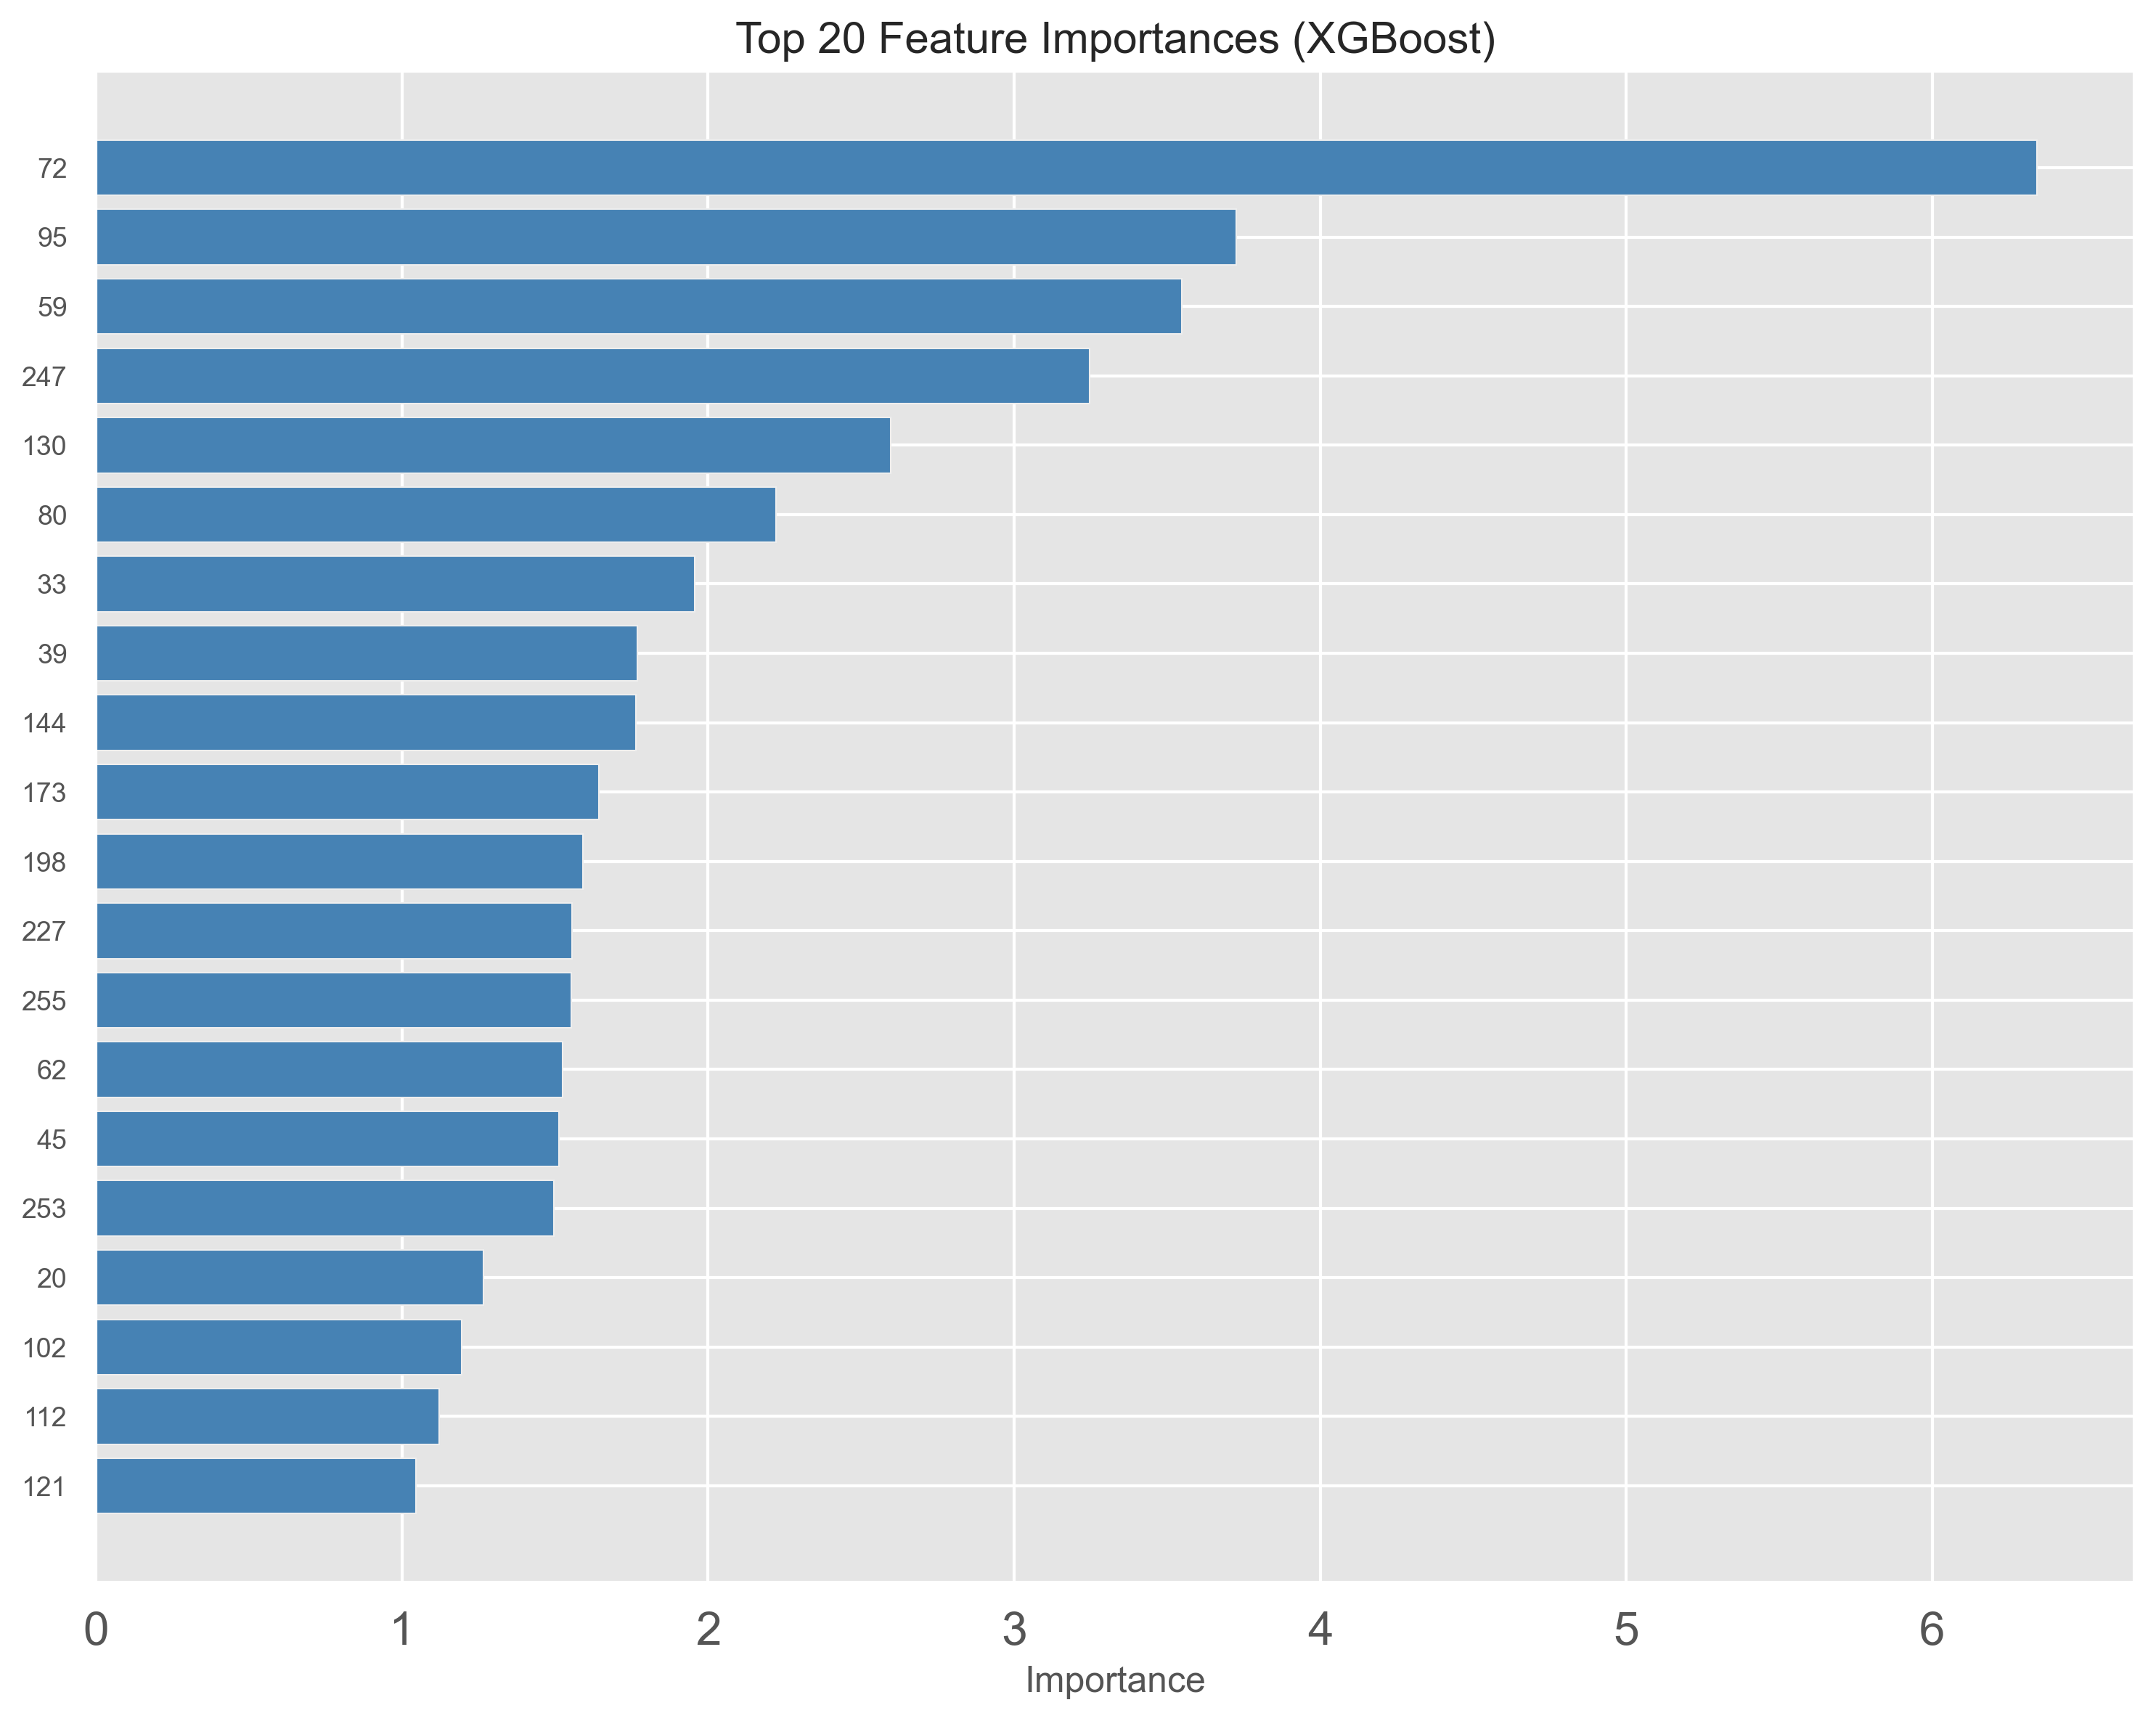

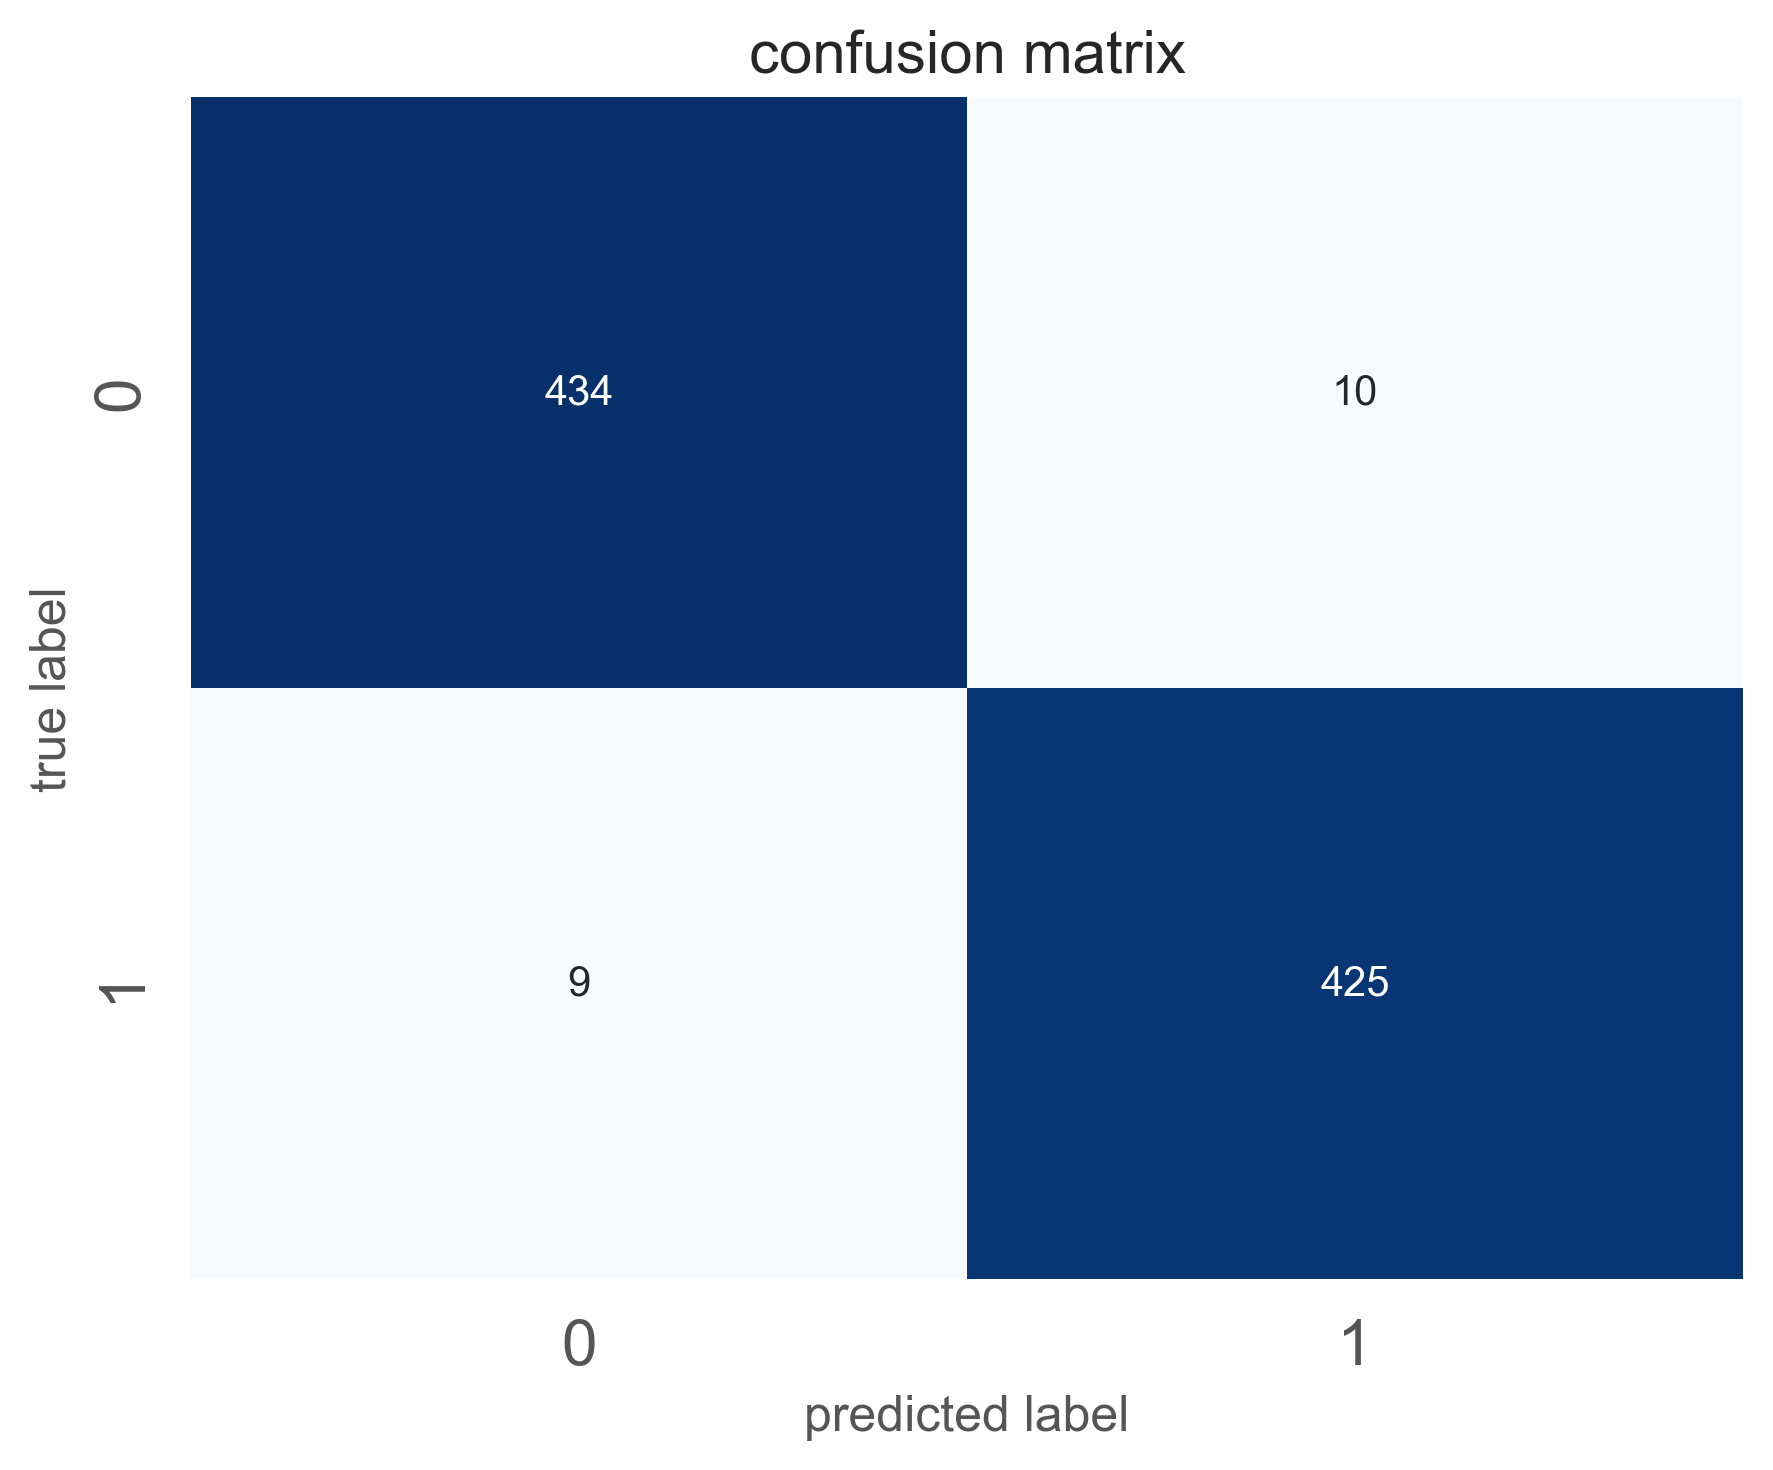

feature_importance.png size (bytes): 107043
confusion_matrix.png size (bytes): 44502
confusion matrix shape: (2, 2)


In [ ]:
import os
from IPython.display import Image, display
#below is just for saving the visualization to put them on the dashboard
top_n = 20
top_features = fT_df.nlargest(top_n, "Importance")  # ensure fT_df exists

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_features["Feature"][::-1], top_features["Importance"][::-1], color="steelblue")
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_n} Feature Importances (XGBoost)")
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
fig.savefig("feature_importance.png", dpi=300, bbox_inches="tight")  #save from fig
plt.close(fig) 
display(Image("feature_importance.png"))
if not isinstance(cm, np.ndarray):
    cm = np.array(cm)

fig, ax = plt.subplots(figsize=(6, 5))
sb.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xlabel("predicted label")
ax.set_ylabel("true label")
ax.set_title("confusion matrix")
plt.tight_layout()
fig.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.close(fig)

# verify file saved (display in notebook)
display(Image("confusion_matrix.png"))

# --- sanity checks: file size and shapes ---
print("feature_importance.png size (bytes):", os.path.getsize("feature_importance.png"))
print("confusion_matrix.png size (bytes):", os.path.getsize("confusion_matrix.png"))
print("confusion matrix shape:", cm.shape)


In [13]:
# messy final  summary
# oversample using smote + xgboost = high recall for minority class (failures)
# gridsearch finds slightly better hyperparameters for depth
# feature importance shows which features matter most, helps explain model
# confusion matrix proves high TP, very few FN